In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
import timeit
from scipy.sparse import csr_array,block_array,eye,coo_array
import subprocess
import struct
from multiprocess import Pool
from IPython.display import Video,display

loadstr=''
try:
    loadstr='module load %s &&'%(subprocess.check_output("module avail | grep cuda/", shell=True, text=True).split()[-1])
except:
    pass

/bin/sh: 1: module: not found


In [2]:
Ns=[256,256,256]
Ls=[200.0,200.0,200.0]

Ns=[64,64,64]
Ls=[100.0,100.0,100.0]

N=Ns[0]

filebase='data/3dcgle'

b=0.0
c=1.5

couplings=['1.0,0,0,1', '1.0,0,8,1', '1.0,0,16,1', '1.0,0,24,1', '-%f,0,9,1'%(b), \
           '-%f,0,17,1'%(b), '-%f,0,25,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,9,1', '1.0,1,17,1', '1.0,1,25,1', '%f,1,8,1'%(b),'%f,1,16,1'%(b), '%f,1,24,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

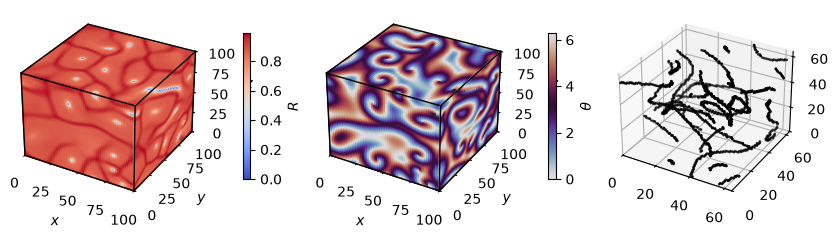

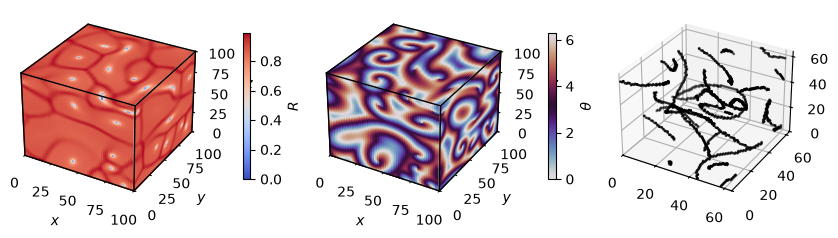

In [52]:
if not os.path.exists(filebase+'animation'):
    os.mkdir(filebase+'animation')

n0=int(200/10)
nt=1000

def wloop(th, axis1=0, axis2=1):
    dth1=np.mod(np.roll(th,-1,axis=axis1)-th+np.pi,2*np.pi)-np.pi
    dth2=np.mod(np.roll(np.roll(th,-1,axis=axis1),-1,axis=axis2)-np.roll(th,-1,axis=axis1)+np.pi,2*np.pi)-np.pi
    dth3=np.mod(np.roll(th,-1,axis=axis2)-np.roll(np.roll(th,-1,axis=axis1),-1,axis=axis2)+np.pi,2*np.pi)-np.pi
    dth4=np.mod(th-np.roll(th,-1,axis=axis2)+np.pi,2*np.pi)-np.pi
    return np.round((dth1+dth2+dth3+dth4)/(2*np.pi))
    
def makeplot(n,show=False,save=True):
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns)
    file.close()

    fig = plt.figure(figsize=(8,3), layout='constrained')
    ax = fig.add_subplot(1,3,1, projection='3d')
    
    R=(ys[0]**2+ys[1]**2)**0.5
    Rmax=np.max(R)
    
    Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
    Z=Ls[2]*np.ones(X.shape)
    C=plt.get_cmap('coolwarm')(R[:,:,-1]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
    Y=0*np.ones(X.shape)
    C=plt.get_cmap('coolwarm')(R[:,0,:].T/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
    X=Ls[0]*np.ones(X.shape)
    C=plt.get_cmap('coolwarm')(R[-1,:,:]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[2])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    
    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(vmin=0, vmax=Rmax)
    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),ax=ax,location='right', label=r'$R$', shrink=0.5, pad=0.2)
    
    ax = fig.add_subplot(1,3,2, projection='3d')
    
    R=np.atan2(ys[1],ys[0])+np.pi
    Rmax=2*np.pi
    
    Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
    Z=Ls[2]*np.ones(X.shape)
    C=plt.get_cmap('twilight')(R[:,:,-1]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
    Y=0*np.ones(X.shape)
    C=plt.get_cmap('twilight')(R[:,0,:].T/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
    X=Ls[0]*np.ones(X.shape)
    C=plt.get_cmap('twilight')(R[-1,:,:]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[2])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    
    cmap = plt.get_cmap('twilight')
    norm = Normalize(vmin=0, vmax=Rmax)
    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),ax=ax,location='right',label=r'$\theta$', shrink=0.5, pad=0.2)

    ax = fig.add_subplot(1,3,3, projection='3d')
    R=np.atan2(ys[1],ys[0])+np.pi
    lines01=coo_array(wloop(R, axis1=0, axis2=1))
    lines12=coo_array(wloop(R, axis1=1, axis2=2))
    lines20=coo_array(wloop(R, axis1=2, axis2=0))
    ax.scatter(*lines01.coords,s=1,c='black')
    ax.scatter(*lines12.coords,s=1,c='black')
    ax.scatter(*lines20.coords,s=1,c='black')
    ax.set_xlim([0,Ns[0]])
    ax.set_ylim([0,Ns[1]])
    ax.set_zlim([0,Ns[2]])

    if save:
        plt.savefig(filebase+'animation/%04d.png'%(n))
    if show:
        plt.show()
    plt.close(fig)

makeplot(0,show=True,save=False)
makeplot(nt,show=True,save=False)

# start=timeit.default_timer()
# pool=Pool(8,maxtasksperchild=1) 
# pool.map(makeplot, range(nt))
# pool.close()
# stop=timeit.default_timer()
# print("plot time: ", stop-start)

# os.system('ffmpeg -y -r 30 -i %sanimation/'%(filebase)+'%04d.png'+ ' -c:v h264 -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2,format=yuv420p" %sanimation.mp4'%(filebase))
# display(Video('%sanimation.mp4'%(filebase)))


In [44]:
n=0

file=open(filebase+'states.dat','rb')
file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns)
file.close()
R=np.atan2(ys[1],ys[0])+np.pi
lines01=np.array(coo_array(wloop(R, axis1=0, axis2=1)).coords)
lines12=np.array(coo_array(wloop(R, axis1=1, axis2=2)).coords)
lines20=np.array(coo_array(wloop(R, axis1=2, axis2=0)).coords)

In [45]:
coord=lines01[:,1]
dx=np.array([1,0,0])
dy=np.array([0,1,0])
dz=np.array([0,0,1])
newcoord=coord+dz
np.where(np.all(newcoord[:,np.newaxis]==lines01,axis=0))
newcoord=coord+dx
np.where(np.all(newcoord[:,np.newaxis]==lines12,axis=0))
newcoord=coord+dy
np.where(np.all(newcoord[:,np.newaxis]==lines20,axis=0))

(array([5]),)

In [55]:
for coord in lines01.T:
    newcoord=coord
    
    t=np.where(np.all(newcoord[:,np.newaxis]==lines12,axis=0))[0]
    if len(t)>0:
        print('1',end=' ')
    t=np.where(np.all(newcoord[:,np.newaxis]==lines20,axis=0))[0]
    if len(t)>0:
        print('2',end=' ')
        
    newcoord=coord+dz
    t=np.where(np.all(newcoord[:,np.newaxis]==lines01,axis=0))[0]
    if len(t)>0:
        print('3',end=' ')
        
    # newcoord=coord-dz
    # t=np.where(np.all(newcoord[:,np.newaxis]==lines01,axis=0))[0]
    # if not len(t)>0:
    #     print('4',end=' ')

    # newcoord=coord+dx
    # t=np.where(np.all(newcoord[:,np.newaxis]==lines12,axis=0))[0]
    # if not len(t)>0:
    #     print('5',end=' ')
    # # newcoord=coord-dx
    # # t=np.where(np.all(newcoord[:,np.newaxis]==lines12,axis=0))[0]
    # # if not len(t)>0:
    # #     print('6',end=' ')

    # newcoord=coord+dy
    # t=np.where(np.all(newcoord[:,np.newaxis]==lines20,axis=0))[0]
    # if not len(t)>0:
    #     print('7',end=' ')
    # # newcoord=coord-dy
    # # t=np.where(np.all(newcoord[:,np.newaxis]==lines20,axis=0))[0]
    # # if not len(t)>0:
    # #     print('8',end=' ')

        
    print()
    

2 
2 
2 
2 

2 
2 

1 
2 
2 
2 


1 




1 3 

2 
2 

3 




2 
3 


2 
1 
3 

2 
1 
2 

3 


2 
2 

2 
2 

1 
1 
2 
2 
2 
1 3 



2 

3 

2 
3 
3 
3 
3 

2 
1 
2 
1 
1 

1 





1 


1 



1 

1 

2 3 




1 
1 
2 

3 
3 
3 
3 
3 


2 
2 
1 


1 

2 
2 
2 
1 
3 

2 

2 
1 
2 3 




3 

1 
2 
2 3 

2 3 


2 
2 
2 3 

3 

2 
3 



1 
3 



1 
1 
2 
2 

1 
2 3 


1 
2 
2 3 
3 

2 3 
3 

2 

1 
2 
2 



1 
2 
1 
2 
2 3 

1 
2 
2 
1 
2 
2 3 

1 
1 
2 
2 3 

2 
2 
2 
2 3 

2 

1 
2 
1 

2 
2 3 

2 
2 
2 
2 
2 
2 
2 
1 
1 
2 
2 
2 
1 3 

2 
2 

2 3 

2 

2 

2 
1 
1 3 

2 
2 


1 
2 3 

2 
1 



1 
1 

2 3 


2 3 

1 
2 
2 
2 
1 
2 

1 


2 
1 

1 



1 
2 

1 


1 
2 3 

1 
1 
1 

2 
2 
1 

2 
2 
2 



1 
2 

2 


1 
2 
1 

2 3 


1 
1 


3 




1 
1 
2 
2 
2 



2 

1 




1 




1 


2 
1 
1 
2 


1 

2 




1 
1 
1 


2 


1 
1 

2 


2 
2 
2 
2 
2 
2 
2 
2 
2 
2 
2 
2 
2 
1 
2 
2 
2 
2 
2 
2 

1 
1 

1 3 

2 
2 
2 
1 
2 3 
3 
3 

2 
2 
2 



2 
1 
2 


2 

2 
2 

2 

1 

2 
2 
2 
2 
2 


In [56]:
lines01

array([[ 0,  0,  0, ..., 63, 63, 63],
       [25, 27, 29, ..., 41, 43, 46],
       [58, 57, 56, ..., 50, 49,  7]], shape=(3, 458))

In [57]:
lines12

array([[ 0,  0,  0, ..., 63, 63, 63],
       [ 2, 22, 32, ..., 47, 52, 57],
       [57, 18, 16, ...,  8, 16, 49]], shape=(3, 568))

In [58]:
lines20

array([[ 0,  0,  0, ..., 63, 63, 63],
       [ 1, 24, 25, ..., 46, 52, 57],
       [57, 59, 58, ...,  8, 16, 49]], shape=(3, 610))

In [60]:
lines=np.concatenate([lines01,lines12,lines20],axis=1)

In [59]:
coord=lines[:,0]
extend=True
while(extend):
    